### Loading Train and Test Data

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

feature_train = pd.read_csv('X_train_prepared.csv',  index_col=0)
target_train = pd.read_csv('y_train_prepared.csv', index_col=0).squeeze()
feature_test = pd.read_csv('X_test_processed.csv',  index_col=0)
target_test = pd.read_csv('y_test.csv', index_col=0).squeeze()

### Creating Polynomial Features

In [2]:

poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_train_poly = poly.fit_transform(feature_train)
X_test_poly  = poly.transform(feature_test)

print(f"Original features: {feature_train.shape[1]}")
print(f"Polynomial features: {X_train_poly.shape[1]}")

Original features: 18
Polynomial features: 189


### Creating and training the Model

In [3]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, target_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Prediction and Calculating MAE, RMSE and R²

In [4]:
y_pred_train_poly = poly_model.predict(X_train_poly)
y_pred_test_poly  = poly_model.predict(X_test_poly)

In [5]:
mae  = mean_absolute_error(target_test, y_pred_test_poly)
rmse = np.sqrt(mean_squared_error(target_test, y_pred_test_poly))
r2   = r2_score(target_test, y_pred_test_poly)
r2_train = r2_score(target_train, y_pred_train_poly)

print(f"\nPolynomial Linear Regression:")
print(f"MAE:          {mae:.4f}")
print(f"RMSE:         {rmse:.4f}")
print(f"R² on train:  {r2_train:.4f}")
print(f"R² on test:   {r2:.4f}")


Polynomial Linear Regression:
MAE:          20.2267
RMSE:         25.5333
R² on train:  0.9923
R² on test:   0.9922


### Plotting for Analysation

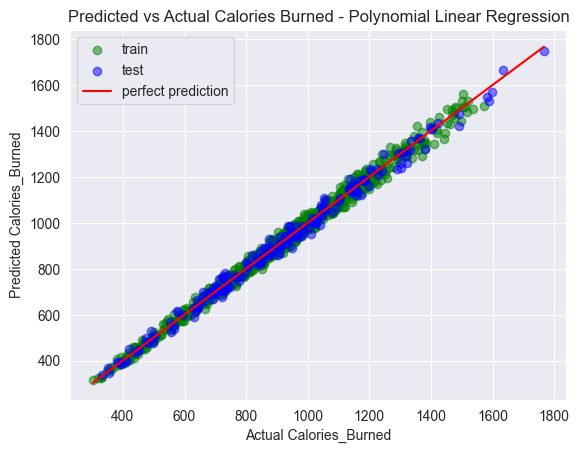

In [6]:
import matplotlib.pyplot as plt


plt.scatter(target_train, y_pred_train_poly, c='green', label='train', alpha=0.5)
plt.scatter(target_test,  y_pred_test_poly,  c='blue',  label='test',  alpha=0.5)

min_val = min(target_train.min(), target_test.min())
max_val = max(target_train.max(), target_test.max())
plt.plot([min_val, max_val], [min_val, max_val], c='red', label='perfect prediction')

plt.xlabel('Actual Calories_Burned')
plt.ylabel('Predicted Calories_Burned')
plt.legend()
plt.title('Predicted vs Actual Calories Burned - Polynomial Linear Regression')
plt.show()